In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from fismi import ismiReplication as fismi

In [2]:
# Import data
niv = '3'

# HICP All Items
colHicp = "INX"

# Unchained other items 
dfICP = pd.read_parquet(f"input/EAunchainedItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/EAnormedWeightsLvl{niv}.parquet") 

In [3]:
# We compute inflation rates on Unchained items - 12-month inflation rate (deals mostly with seasonality) - monthly frequency
dfInflation = np.log(dfICP).diff(12)[12:]
InflTot = dfInflation["INX"].to_frame()
dfInflation = dfInflation.drop("INX",axis=1)

In [4]:
# Call functions
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(dfInflation, rolling_window=120)
posItems, negItems, posIsmi, negIsmi, ismIndex = fismi.replicateIsmi(dfInflation, df_shocks, dfW)

Step 1 : Estimate 126 AR(1) on a 120 month rolling window...
Step 2 : Compute inflation momentum and aggregate...
Done


In [5]:
# Merge
ismIndex = ismIndex.to_frame().merge(
    InflTot,
    how="left",
    left_index=True,
    right_index=True)

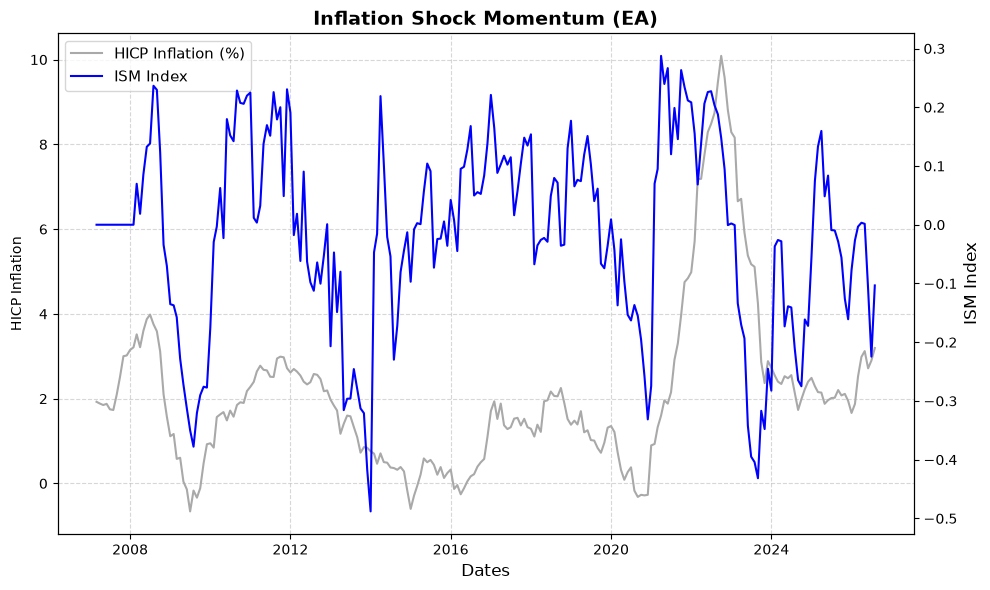

In [6]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    ismIndex["INX"]*100,
    label="HICP Inflation (%)",
    color="darkgrey",
    linewidth=1.5,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("HICP Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    ismIndex["ISMIndex"],
    label="ISM Index",
    color="blue",
    linewidth=1.5,
)

ax2.set_ylabel("ISM Index", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Inflation Shock Momentum (EA)", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

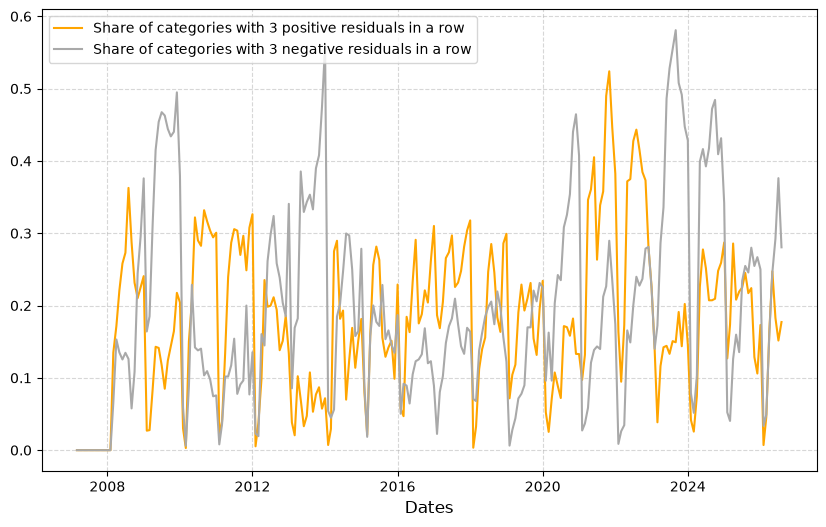

In [7]:
# Positive and negative contributions
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = posIsmi.index
ax.plot(
    x_axis,
    posIsmi.values,
    color="orange",
    label="Share of categories with 3 positive residuals in a row",
    linewidth=1.5,
)

ax.plot(
    x_axis,
    negIsmi.values,
    label="Share of categories with 3 negative residuals in a row",
    color="darkgrey",
    linewidth=1.5,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

In [9]:
# Réplication Figure A1
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(InflTot)

# Drop NaN and merge
HICP = InflTot.copy()
HICP["Shocks"] = df_shocks.values
HICP["A"] = aCoef.values
HICP["Rho"] = rhoCoef.values
HICP = HICP.dropna()

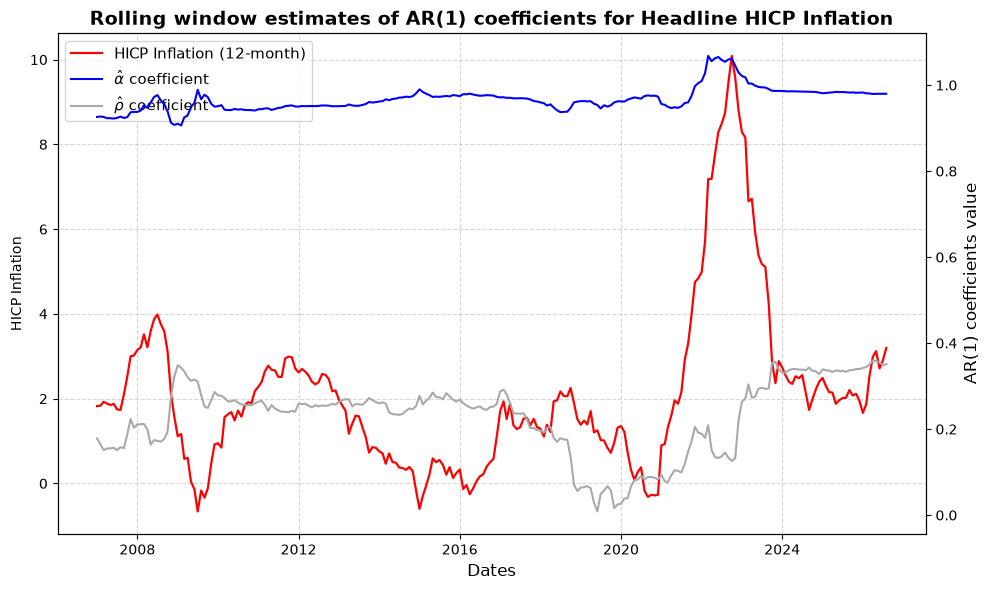

In [10]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    HICP["INX"]*100,
    label="HICP Inflation (12-month)",
    color="red",
    linewidth=1.6,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("HICP Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    HICP["A"],
    label=r'$\hat \alpha$ coefficient',
    color="blue",
    linewidth=1.5,
)

ax2.plot(
    HICP["Rho"],
    label=r'$\hat \rho$ coefficient',
    color="darkgrey",
    linewidth=1.5,
)

ax2.set_ylabel("AR(1) coefficients value", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Rolling window estimates of AR(1) coefficients for Headline HICP Inflation", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

plt.tight_layout()
plt.show()

When $\alpha = 0$ the shocks tend to die out immediately. If positive, they are self reinforcing.